In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("best_data.csv")

In [3]:
df['Status'] = np.where(df['Percent_Bleaching'] <= 1, True, False)
X = df.drop(columns=["Percent_Bleaching", "Status"])   # ⭐ ลบทั้งคู่
Y = df["Status"]

# PCA

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Class distribution:")
print(Y.value_counts())
print(Y.value_counts(normalize=True).round(3))
print(y_test[y_test == True].count()/y_test.count()*100)
print(y_train[y_train == True].count()/y_train.count()*100)

Class distribution:
Status
True     12088
False     9840
Name: count, dtype: int64
Status
True     0.551
False    0.449
Name: proportion, dtype: float64
55.608755129958965
55.005130543837645


In [6]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [7]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [8]:
pca = PCA(n_components=0.75)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

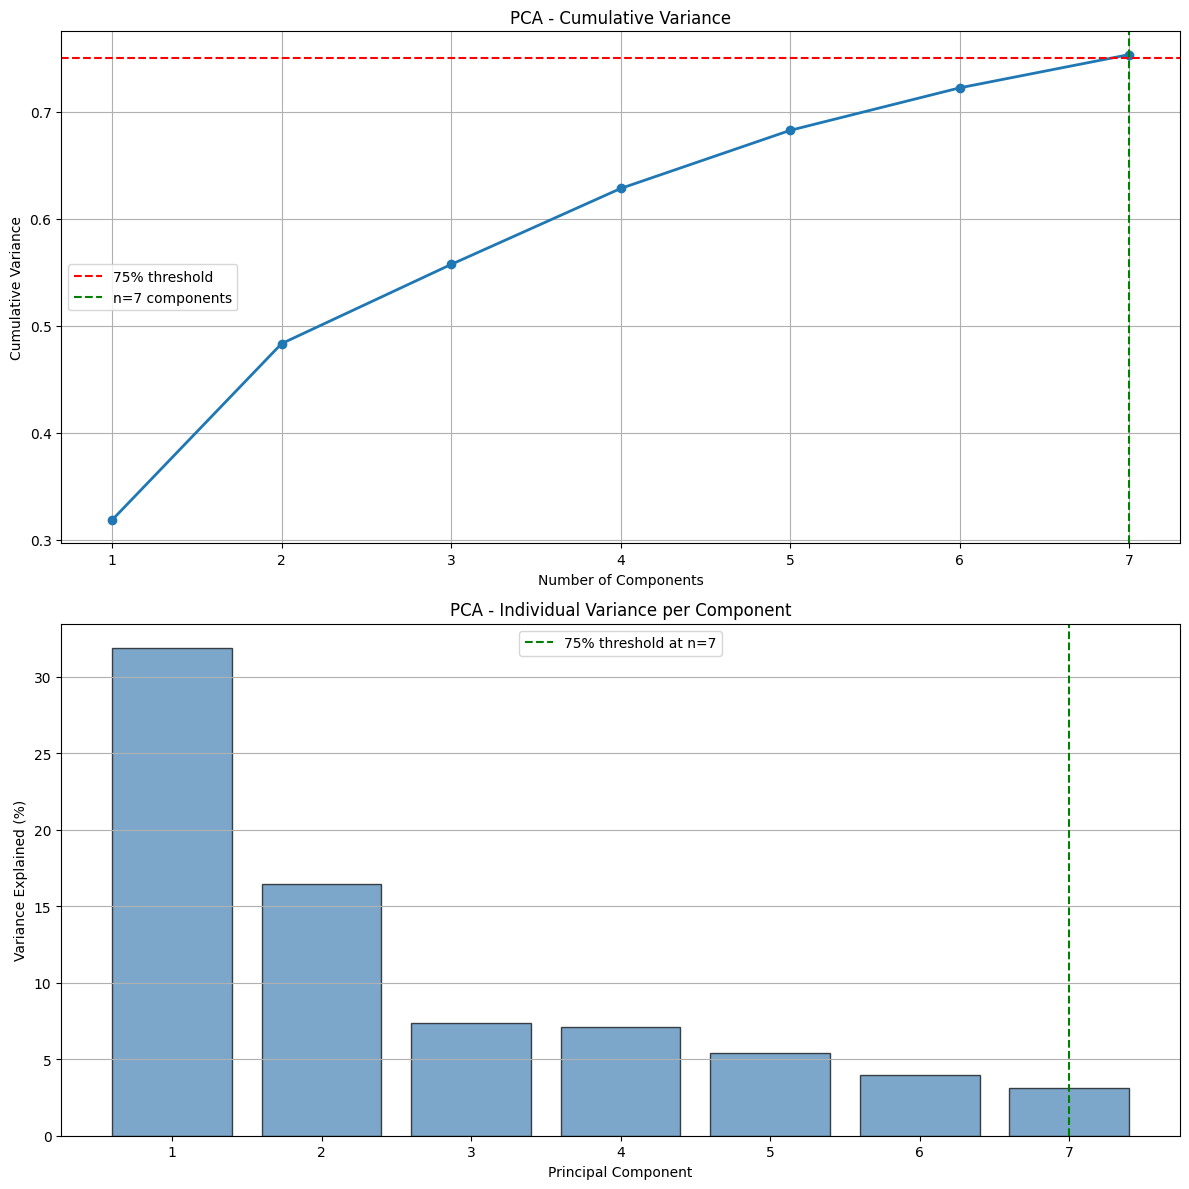

✅ Components needed for 75% variance: 7
✅ Variance explained by 7 components: 0.7535


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [10]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_df,  X_test_raw_month,  X_test_fe],       axis=1)

In [11]:
import optuna
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Optuna

In [12]:
# ============================================================
# Helper: CV with proper preprocessing within fold
# ============================================================
def cv_classif(model_factory, X_num, X_extras, y, cv_splits=5):
    """
    Stratified K-Fold CV ที่ fit preprocessing ใน fold เพื่อป้องกัน data leakage
    
    Args:
        model_factory: callable ที่ return model object ใหม่ (สำหรับ Bagging)
                       หรือ tuple (model_class, params) สำหรับ models ทั่วไป
        X_num:    DataFrame for PCA pipeline
        X_extras: DataFrame to concat after PCA (month + paper features)
        y:        target Series
        cv_splits: number of folds
    
    Returns:
        Mean F1-weighted score across folds
    """
    X_num    = X_num.reset_index(drop=True)
    X_extras = X_extras.reset_index(drop=True)
    y        = y.reset_index(drop=True)
    
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X_num, y):
        # ----- split -----
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_ex_tr  = X_extras.iloc[train_idx].reset_index(drop=True)
        X_ex_val = X_extras.iloc[val_idx].reset_index(drop=True)
        y_tr     = y.iloc[train_idx].reset_index(drop=True)
        y_val    = y.iloc[val_idx].reset_index(drop=True)
        
        # ----- fit preprocessing บน train fold เท่านั้น ⭐ -----
        imputer = SimpleImputer(strategy='median')
        X_tr_imp  = imputer.fit_transform(X_num_tr)
        X_val_imp = imputer.transform(X_num_val)
        
        scaler = StandardScaler()
        X_tr_ss  = scaler.fit_transform(X_tr_imp)
        X_val_ss = scaler.transform(X_val_imp)
        
        pca = PCA(n_components=0.75)
        X_tr_pca  = pca.fit_transform(X_tr_ss)
        X_val_pca = pca.transform(X_val_ss)
        
        # ----- reattach extras -----
        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_ex_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_ex_val], axis=1)
        
        # ----- train + evaluate -----
        model = model_factory()    # สร้าง model ใหม่ทุก fold
        model.fit(X_tr_final, y_tr)
        y_pred = model.predict(X_val_final)
        scores.append(f1_score(y_val, y_pred, average='weighted'))
    
    return np.mean(scores)


# ============================================================
# Prepare extras (จะ concat หลัง PCA)
# ============================================================
X_extras_train = pd.concat([
    X_train_raw_month.reset_index(drop=True),
    X_train_raw_fe.reset_index(drop=True)
], axis=1)


# ============================================================
# 1. Random Forest
# ============================================================
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', None]),
        'random_state':      42,
        'n_jobs':            -1,
    }
    
    def make_model():
        return RandomForestClassifier(**params)
    
    return cv_classif(make_model, X_train_raw, X_extras_train, y_train)


# ============================================================
# 2. Extra Trees
# ============================================================
def objective_et(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', None]),
        'random_state':      42,
        'n_jobs':            -1,
    }
    
    def make_model():
        return ExtraTreesClassifier(**params)
    
    return cv_classif(make_model, X_train_raw, X_extras_train, y_train)


# ============================================================
# 3. Bagging (special - has base estimator)
# ============================================================
def objective_bagging(trial):
    base_max_depth        = trial.suggest_int('base_max_depth', 5, 30)
    base_min_samples_leaf = trial.suggest_int('base_min_samples_leaf', 1, 10)
    
    bagging_params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 300),
        'max_samples':     trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features':    trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap':       trial.suggest_categorical('bootstrap', [True, False]),
        'random_state':    42,
        'n_jobs':          -1,
    }
    
    def make_model():
        # สร้าง base + Bagging ใหม่ทุกครั้ง
        base = DecisionTreeClassifier(
            max_depth=base_max_depth,
            min_samples_leaf=base_min_samples_leaf,
            random_state=42
        )
        return BaggingClassifier(estimator=base, **bagging_params)
    
    return cv_classif(make_model, X_train_raw, X_extras_train, y_train)


# ============================================================
# Run all 3 studies
# ============================================================
studies = {}
n_trials = 50

# ---------- Random Forest ----------
print("=" * 60)
print("🌲 Tuning Random Forest...")
print("=" * 60)
studies['rf'] = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
studies['rf'].optimize(objective_rf, n_trials=n_trials, show_progress_bar=True)

# ---------- Extra Trees ----------
print("\n" + "=" * 60)
print("🌳 Tuning Extra Trees...")
print("=" * 60)
studies['et'] = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
studies['et'].optimize(objective_et, n_trials=n_trials, show_progress_bar=True)

# ---------- Bagging ----------
print("\n" + "=" * 60)
print("👜 Tuning Bagging...")
print("=" * 60)
studies['bagging'] = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
studies['bagging'].optimize(objective_bagging, n_trials=n_trials, show_progress_bar=True)


# ============================================================
# Summary
# ============================================================
print("\n" + "=" * 60)
print("📊 Best Results")
print("=" * 60)
for name, study in studies.items():
    print(f"\n{name.upper()}:")
    print(f"  Best F1:     {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

[I 2026-05-08 10:46:17,009] A new study created in memory with name: no-name-d12f9ba8-a791-4ffd-ad2d-c5fdc0fdd806


🌲 Tuning Random Forest...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-08 10:46:22,765] Trial 0 finished with value: 0.9011753740714841 and parameters: {'n_estimators': 350, 'max_depth': 48, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9011753740714841.
[I 2026-05-08 10:46:37,721] Trial 1 finished with value: 0.897921584743799 and parameters: {'n_estimators': 223, 'max_depth': 45, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.9011753740714841.
[I 2026-05-08 10:47:13,338] Trial 2 finished with value: 0.915727419677309 and parameters: {'n_estimators': 533, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.915727419677309.
[I 2026-05-08 10:47:38,946] Trial 3 finished with value: 0.914136857810594 and parameters: {'n_estimators': 373, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.915727419677309.
[I 2026

[I 2026-05-08 11:01:08,830] A new study created in memory with name: no-name-226d5fbf-9892-4cea-85ab-7b1ec0c11385


...

[I 2026-05-08 11:01:11,942] Trial 0 finished with value: 0.8683710426266117 and parameters: {'n_estimators': 350, 'max_depth': 48, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8683710426266117.
[I 2026-05-08 11:01:16,305] Trial 1 finished with value: 0.8979661967100008 and parameters: {'n_estimators': 223, 'max_depth': 45, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.8979661967100008.
[I 2026-05-08 11:01:25,965] Trial 2 finished with value: 0.9226683424470601 and parameters: {'n_estimators': 533, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.9226683424470601.
[I 2026-05-08 11:01:32,789] Trial 3 finished with value: 0.9177821477965846 and parameters: {'n_estimators': 373, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.9226683424470601.
[I

[I 2026-05-08 11:06:22,027] A new study created in memory with name: no-name-e86d6b30-99b0-4088-95e4-ec75204838cc


[I 2026-05-08 11:06:22,024] Trial 49 finished with value: 0.9278528472425653 and parameters: {'n_estimators': 423, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 22 with value: 0.9282077632976226.

👜 Tuning Bagging...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-08 11:06:32,776] Trial 0 finished with value: 0.8621411053526907 and parameters: {'base_max_depth': 14, 'base_min_samples_leaf': 10, 'n_estimators': 233, 'max_samples': 0.7993292420985183, 'max_features': 0.5780093202212182, 'bootstrap': True}. Best is trial 0 with value: 0.8621411053526907.
[I 2026-05-08 11:06:43,415] Trial 1 finished with value: 0.858543559979756 and parameters: {'base_max_depth': 27, 'base_min_samples_leaf': 7, 'n_estimators': 227, 'max_samples': 0.5102922471479012, 'max_features': 0.9849549260809971, 'bootstrap': True}. Best is trial 0 with value: 0.8621411053526907.
[I 2026-05-08 11:06:50,197] Trial 2 finished with value: 0.8509464979611459 and parameters: {'base_max_depth': 9, 'base_min_samples_leaf': 2, 'n_estimators': 126, 'max_samples': 0.762378215816119, 'max_features': 0.7159725093210578, 'bootstrap': False}. Best is trial 0 with value: 0.8621411053526907.
[I 2026-05-08 11:06:58,069] Trial 3 finished with value: 0.8309613512466397 and parameters: 

# K-Fold

In [ ]:
# BAGGING {'base_max_depth': 20, 'base_min_samples_leaf': 1, 'n_estimators': 90, 'max_samples': 0.9869618111006297, 'max_features': 0.6939338393935504, 'bootstrap': False}
# ET {'n_estimators': 423, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 22 with value: 0.9282077632976226.
# RF {'n_estimators': 500, 'max_depth': 45, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 44 with value: 0.9270635388127841.

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, 
    BaggingClassifier, VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)
import numpy as np
import pandas as pd

# ============================================================
# Best params from Optuna
# ============================================================
# Save best params (สำหรับ K-Fold ภายหลัง)
rf_best  = studies['rf'].best_params
et_best  = studies['et'].best_params
bg_best  = studies['bagging'].best_params

# RF
rf_best_params = {**rf_best, 'random_state': 42, 'n_jobs': -1}

# ET
et_best_params = {**et_best, 'random_state': 42, 'n_jobs': -1}

# Bagging (แยก base params จาก main params)
bagging_base_max_depth = bg_best.pop('base_max_depth')
bagging_base_min_samples_leaf = bg_best.pop('base_min_samples_leaf')
bagging_other_params = {**bg_best, 'random_state': 42, 'n_jobs': -1}

def make_bagging():
    """Helper สร้าง Bagging ใหม่ทุกครั้ง (เพราะมี base estimator)"""
    base_tree = DecisionTreeClassifier(
        max_depth=bagging_base_max_depth,
        min_samples_leaf=bagging_base_min_samples_leaf,
        random_state=42
    )
    return BaggingClassifier(estimator=base_tree, **bagging_other_params)


# ============================================================
# Models to evaluate
# ============================================================
def make_models():
    """สร้าง models ใหม่ทุก fold (สำคัญ! ป้องกัน fit ซ้อน)"""
    rf  = RandomForestClassifier(**rf_best_params)
    et  = ExtraTreesClassifier(**et_best_params)
    bg  = make_bagging()
    
    voting_hard = VotingClassifier(
        estimators=[('rf', rf), ('et', et), ('bg', bg)],
        voting='hard'
    )
    
    voting_soft = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(**rf_best_params)),
            ('et', ExtraTreesClassifier(**et_best_params)),
            ('bg', make_bagging())
        ],
        voting='soft'
    )
    
    return {
        'RandomForest':       RandomForestClassifier(**rf_best_params),
        'ExtraTrees':         ExtraTreesClassifier(**et_best_params),
        'Bagging':            make_bagging(),
        'Voting (Hard)':      voting_hard,
        'Voting (Soft)':      voting_soft,
    }


# ============================================================
# K-Fold Cross Validation
# ============================================================
n_splits = 4
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']
paper_features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

X_month = X[month_cols].copy()
X_paper = X[paper_features].copy()
X_for_pca = X.drop(columns=month_cols)

# ============================================================
# เก็บผล
# ============================================================
results = {name: {'acc': [], 'bal_acc': [], 'prec': [], 'rec': [], 'f1': []}
           for name in make_models().keys()}

print("=" * 80)
print(f"K-Fold Cross Validation Summary (k={n_splits}, Stratified)")
print("=" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_for_pca, Y), 1):    
    # ------ split data ------
    X_fold_train, X_fold_test = X_for_pca.iloc[train_idx], X_for_pca.iloc[test_idx]
    month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
    month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
    paper_fold_train = X_paper.iloc[train_idx].copy()
    paper_fold_test  = X_paper.iloc[test_idx].copy()
    y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
    y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)
    
    # ------ impute / scale / PCA ------
    imputer     = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_fold_train)
    X_test_imp  = imputer.transform(X_fold_test)
    
    fe_imputer  = SimpleImputer(strategy='median')
    paper_fold_train = pd.DataFrame(
        fe_imputer.fit_transform(paper_fold_train),
        columns=paper_features
    ).reset_index(drop=True)
    paper_fold_test = pd.DataFrame(
        fe_imputer.transform(paper_fold_test),
        columns=paper_features
    ).reset_index(drop=True)
    
    scaler      = StandardScaler()
    X_train_ss  = scaler.fit_transform(X_train_imp)
    X_test_ss   = scaler.transform(X_test_imp)
    
    pca         = PCA(n_components=0.75)
    X_train_pca_fold = pca.fit_transform(X_train_ss)
    X_test_pca_fold  = pca.transform(X_test_ss)
    
    # ------ reattach: PCA + month + paper(imputed) ------
    n_pcs   = X_train_pca_fold.shape[1]
    pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
    
    X_train_final = pd.concat([
        pd.DataFrame(X_train_pca_fold, columns=pc_cols),
        month_fold_train,
        paper_fold_train,
    ], axis=1)
    X_test_final  = pd.concat([
        pd.DataFrame(X_test_pca_fold, columns=pc_cols),
        month_fold_test,
        paper_fold_test,
    ], axis=1)
    
    # ------ train & evaluate each model ------
    fold_models = make_models()   # สร้างใหม่ทุก fold
    
    for name, model in fold_models.items():
        model.fit(X_train_final, y_fold_train)
        y_pred = model.predict(X_test_final)
        
        results[name]['acc'].append(accuracy_score(y_fold_test, y_pred))
        results[name]['bal_acc'].append(balanced_accuracy_score(y_fold_test, y_pred))
        results[name]['prec'].append(precision_score(y_fold_test, y_pred, average='weighted', zero_division=0))
        results[name]['rec'].append(recall_score(y_fold_test, y_pred, average='weighted', zero_division=0))
        results[name]['f1'].append(f1_score(y_fold_test, y_pred, average='weighted', zero_division=0))

# ============================================================
# Summary Table — Mean ± Std
# ============================================================
print("\n" + "=" * 95)
print(f"📊 Final Results — Mean ± Std across {n_splits} folds")
print("=" * 95)
print(f"{'Model':<22}{'Accuracy':>14}{'Balanced Acc':>16}"
      f"{'Precision':>14}{'Recall':>12}{'F1 Score':>14}")
print("-" * 95)

for name, scores in results.items():
    print(
        f"{name:<22}"
        f"{np.mean(scores['acc']):.4f} ±{np.std(scores['acc']):.4f}"
        f"  {np.mean(scores['bal_acc']):.4f} ±{np.std(scores['bal_acc']):.4f}"
        f"  {np.mean(scores['prec']):.4f} ±{np.std(scores['prec']):.4f}"
        f"  {np.mean(scores['rec']):.4f} ±{np.std(scores['rec']):.4f}"
        f"  {np.mean(scores['f1']):.4f} ±{np.std(scores['f1']):.4f}"
    )
print("=" * 95)


# ============================================================
# สร้าง DataFrame สำหรับ paper / save
# ============================================================
summary_df = pd.DataFrame({
    name: {
        'Accuracy_Mean':          np.mean(scores['acc']),
        'Accuracy_Std':           np.std(scores['acc']),
        'BalancedAcc_Mean':       np.mean(scores['bal_acc']),
        'BalancedAcc_Std':        np.std(scores['bal_acc']),
        'Precision_Mean':         np.mean(scores['prec']),
        'Precision_Std':          np.std(scores['prec']),
        'Recall_Mean':            np.mean(scores['rec']),
        'Recall_Std':             np.std(scores['rec']),
        'F1_Mean':                np.mean(scores['f1']),
        'F1_Std':                 np.std(scores['f1']),
    }
    for name, scores in results.items()
}).T.round(4)

print("\n📋 Summary DataFrame:")
print(summary_df)

K-Fold Cross Validation Summary (k=4, Stratified)

📊 Final Results — Mean ± Std across 4 folds
Model                       Accuracy    Balanced Acc     Precision      Recall      F1 Score
-----------------------------------------------------------------------------------------------
RandomForest          0.9401 ±0.0036  0.9380 ±0.0037  0.9403 ±0.0036  0.9401 ±0.0036  0.9400 ±0.0036
ExtraTrees            0.9393 ±0.0032  0.9377 ±0.0030  0.9394 ±0.0033  0.9393 ±0.0032  0.9392 ±0.0032
Bagging               0.9398 ±0.0029  0.9379 ±0.0031  0.9399 ±0.0029  0.9398 ±0.0029  0.9397 ±0.0029
Voting (Hard)         0.9405 ±0.0027  0.9387 ±0.0027  0.9406 ±0.0028  0.9405 ±0.0027  0.9404 ±0.0027
Voting (Soft)         0.9408 ±0.0032  0.9391 ±0.0031  0.9409 ±0.0033  0.9408 ±0.0032  0.9407 ±0.0032

📋 Summary DataFrame:
               Accuracy_Mean  Accuracy_Std  BalancedAcc_Mean  BalancedAcc_Std  \
RandomForest          0.9401        0.0036            0.9380           0.0037   
ExtraTrees            0.939